In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Import CellRefiner and packages

In [26]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc
import sys
sys.path.append('..')
import cellrefiner as cr

# 2. Load Data

The paired datasets here are from Visium spatial transcriptomic data and scRNA-seq samples of the mouse cortex available via the squidpy package.

In [27]:
adata_st = sc.read_h5ad(f'../../data/Human_SCC/Human_SCC_ST.h5ad')
adata_sc = sc.read_h5ad(f'../../data/Human_SCC/Human_SCC_SC.h5ad')
cluster_key_st = 'leiden'
cluster_key_sc = 'level2_celltype'
spatial_key = 'spatial'
# remove Multiplet
exclude_types = ['Multiplet']
I = ~adata_sc.obs[cluster_key_sc].isin(exclude_types)
#  only select tumor sample
I = I & (adata_sc.obs['tum.norm']=='Tumor') 
adata_sc = adata_sc[I].copy()
print('SC:\n',adata_sc)
print('ST:\n',adata_st)

SC:
 AnnData object with n_obs × n_vars = 25506 × 32738
    obs: 'nCount_RNA', 'nFeature_RNA', 'patient', 'tum.norm', 'level1_celltype', 'level2_celltype', 'level3_celltype'
    uns: 'level1_celltype_colors', 'level2_celltype_colors', 'level3_celltype_colors', 'log1p', 'neighbors', 'patient_colors', 'pca', 'tum.norm_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
ST:
 AnnData object with n_obs × n_vars = 646 × 17344
    obs: 'leiden'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca'
    obsm: 'X_pca', 'spatial', 'spot_to_cell', 'spot_to_sc'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


Load the mouse ligand-receptor database from local path, originally sourced from CellChat

In [28]:
db = pd.read_csv(R'LR.csv')
scale = 125
adata_cr = cr.pp.spatial_mapping(adata_st,adata_sc,db,scale=scale,cluster_key_sc = cluster_key_sc)
print(adata_cr)

/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)


/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 3230 × 32738
    obs: 'nCount_RNA', 'nFeature_RNA', 'patient', 'tum.norm', 'level1_celltype', 'level2_celltype', 'level3_celltype'
    uns: 'level1_celltype_colors', 'level2_celltype_colors', 'level3_celltype_colors', 'log1p', 'neighbors', 'patient_colors', 'pca', 'tum.norm_colors', 'umap', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


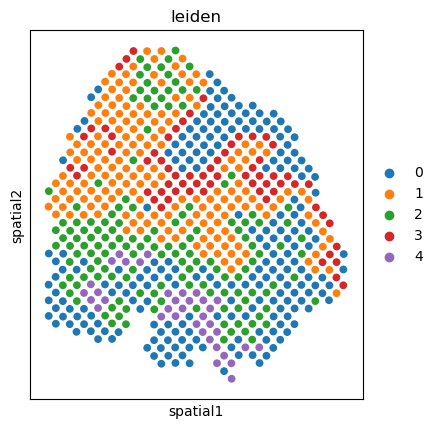

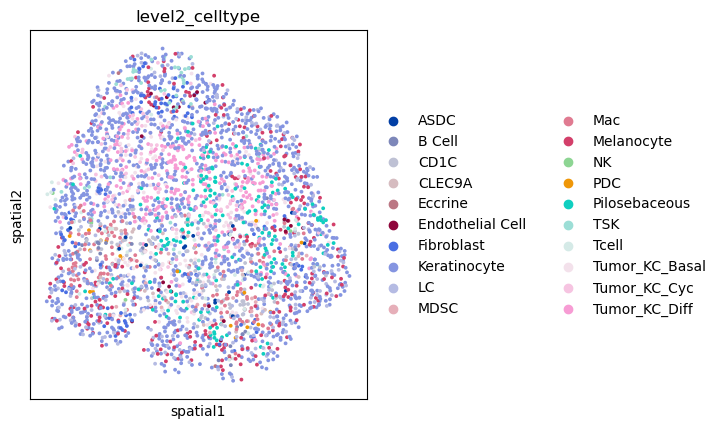

In [29]:
sc.pl.spatial(adata_st, color = cluster_key_st,spot_size = 200)
sc.pl.spatial(adata_cr, color = cluster_key_sc,spot_size = 100)

In [30]:
sem = cr.tl.cell_shape_modeling(adata_cr,cluster_key = cluster_key_sc)

Simulation: 100%|██████████| 2000/2000 [01:29<00:00, 22.22it/s]


add .obsp['contacts'], .uns['contacts']
Computing alpha-shape with parameters: alpha=None, ns=10, r=1.2


Processing Cell Shapes: 100%|██████████| 3230/3230 [00:32<00:00, 100.04it/s]


<Axes: >

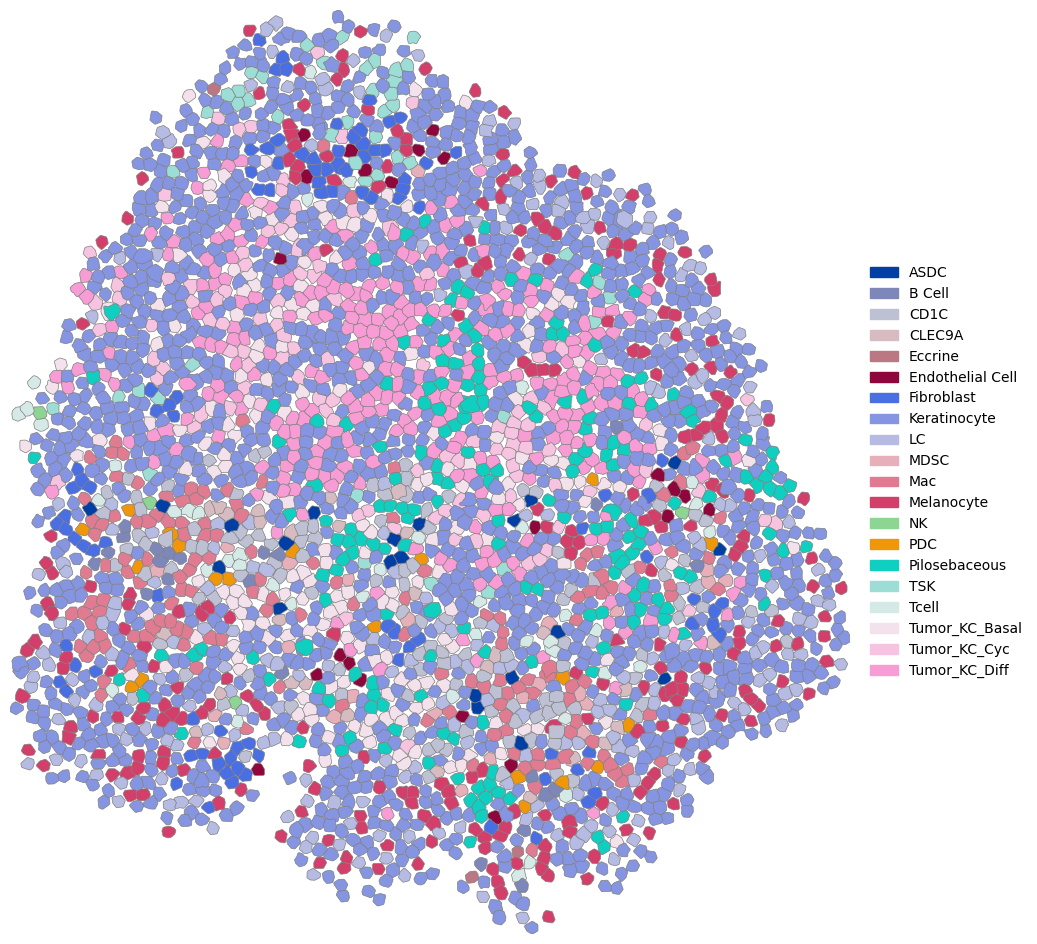

In [31]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5)

In [36]:
db_lr = cr.pp.ligand_receptor_database(species='human')
db_lr = cr.pp.filter_lr_database(db_lr,adata_cr, min_cell_pct=0.01)
cr.tl.contact_communication(db_lr, adata = adata_cr)

add .uns['contact_signal_info']
add .obsm['sender_signal'], .obsm['receiver_signal']


<Axes: >

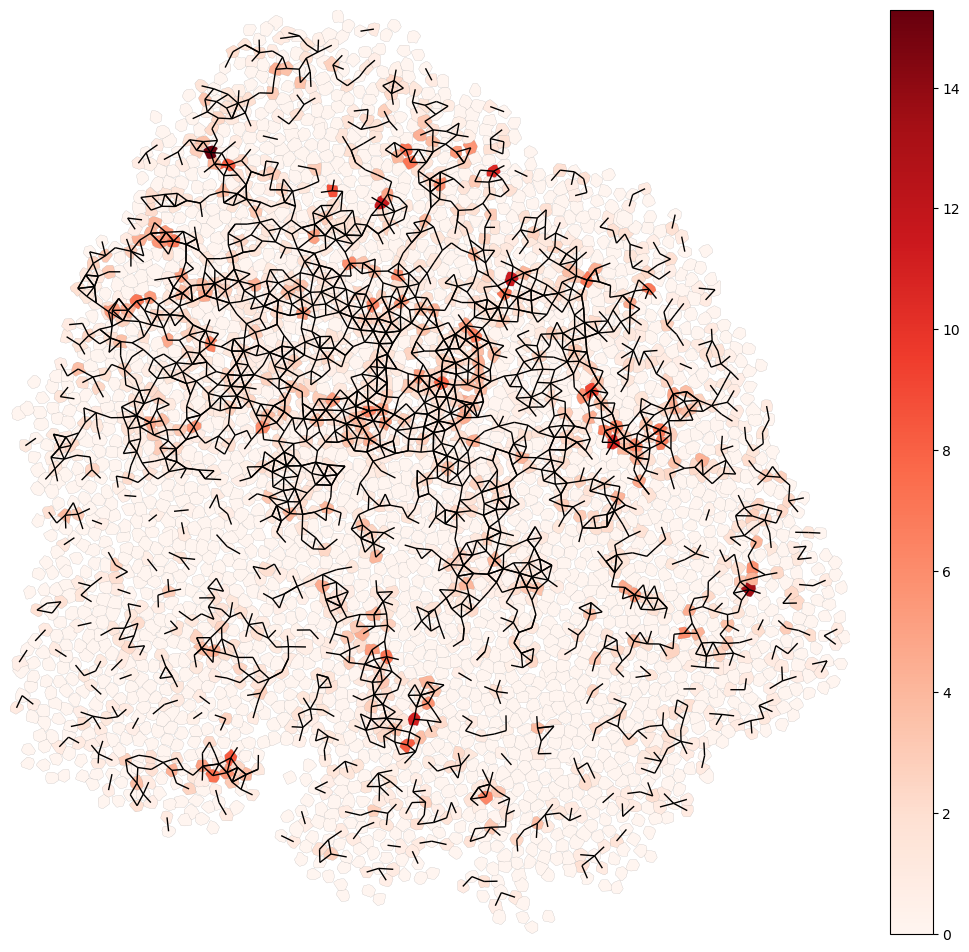

In [37]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,vis_key='NOTCH',boundary_color='gray',boundary_width=0.1)
cr.pl.plot_contact_signal(sem,ax=ax,signal = 'NOTCH')

<Axes: >

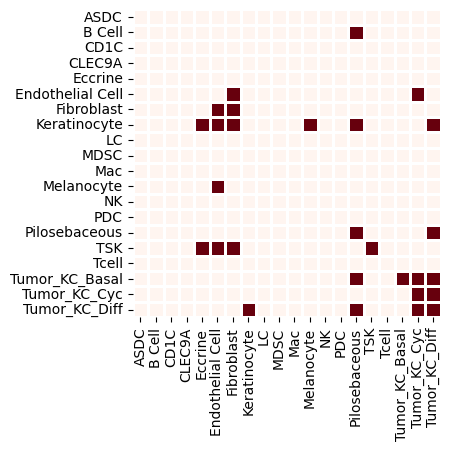

In [38]:
cr.tl.cluster_communication(adata_cr,cluster_key = cluster_key_sc,signal = 'NOTCH')
fig,ax=plt.subplots(figsize=(6,4))
sns.heatmap(adata_cr.uns[f'{cluster_key_sc}-NOTCH']['communication_pvalue']<0.05,square=True,linewidths=1,ax=ax,cmap='Reds',cbar=False)